In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn import metrics
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys

In [18]:
from tdc.single_pred import ADME
data = ADME(name = 'Solubility_AqSolDB')
split = data.get_split()
split.keys()


Found local copy...
Loading...
Done!


dict_keys(['train', 'valid', 'test'])

In [19]:
train_data = split["train"]
val_data = split["valid"]
test_data = split["test"]

In [20]:
train_data.head()
val_data.head()
test_data.head()

,Drug_ID,Drug,Y
0,"2-ethyl-9,10-dihydroanthracene-9,10-dione",CCc1ccc2c(c1)C(=O)c1ccccc1C2=O,-5.984242
1,Digoxin,CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CC...,-4.160000
2,diphenic acid,O=C(O)c1ccccc1-c1ccccc1C(=O)O,-2.283900
3,pentachlorobutadiene,ClC(Cl)=CC(Cl)=C(Cl)Cl,-4.230000
4,trimethyl phosphate,COP(=O)(OC)OC,0.552600


In [29]:
try_smiles = train_data['Drug'][0]

In [30]:
try_smiles

'O=C1Nc2cccc3cccc1c23'

In [32]:
mol_obj = Chem.MolFromSmiles(try_smiles)
np.array(AllChem.GetMorganFingerprintAsBitVect(mol_obj,radius = 4, nBits = 512))
np.array(AllChem.GetMACCSKeysFingerprint(mol_obj))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0])

In [53]:
def create_dataset_morgan(data):
    fp_lst = []
    smiles_lst = list(data['Drug'])
    y_data = list(data['Y'])
    y_data_clean = []
    for smiles, y_value in zip(smiles_lst, y_data):
        mol = Chem.MolFromSmiles(smiles)
        if mol != None:
            fp_lst.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius = 4, nBits=512)))
            y_data_clean.append(y_value)
        else:
            continue
    return fp_lst, y_data_clean

In [61]:
def create_dataset_maccs(data):
    fp_lst = []
    smiles_lst = list(data['Drug'])
    y_data = list(data['Y'])
    y_data_clean =[]
    for smiles, y_value in zip(smiles_lst,y_data):
        if Chem.MolFromSmiles(smiles) != None:
            fp_lst.append(np.array(AllChem.GetMACCSKeysFingerprint(Chem.MolFromSmiles(smiles))))
            y_data_clean.append(y_value)
        else:
            continue        
    return fp_lst, y_data_clean

In [59]:
train_data_morgan, train_y_morgan = create_dataset_morgan (train_data)
val_data_morgan, val_y_morgan = create_dataset_morgan (val_data)
test_data_morgan, test_y_morgan = create_dataset_morgan(test_data)

In [ ]:
#Test: 
# Chem.MolFromSmiles('CC1=CC=C[NH+2]([O-])[CH-]1')

In [64]:
train_data_maccs, train_y_maccs = create_dataset_maccs (train_data)
val_data_maccs, val_y_maccs = create_dataset_maccs (val_data)
test_data_maccs, test_y_maccs = create_dataset_maccs(test_data)

In [74]:
def rf_model(train_x,train_y):
    model = RandomForestRegressor(random_state = 42).fit(train_x, train_y)
    return model

def svm_model(train_x, train_y):
    model = SVR()
    model.fit(train_x,train_y)
    return model

In [68]:
morgan_rf = rf_model(train_data_morgan, train_y_morgan)

In [ ]:
morgan_svm = svm_model(np.array(train_data_morgan), np.array(train_y_morgan)) 

In [77]:
maccs_rf = rf_model(train_data_maccs, train_y_maccs)
maccs_svm = svm_model(np.array(train_data_maccs), np.array(train_y_maccs)) 

In [95]:
np.array(test_data_morgan).shape

(1996, 512)

In [96]:
prediction_morgan_rf = morgan_rf.predict(test_data_morgan)
prediction_morgan_svm = morgan_svm.predict(test_data_morgan)
rf_mae = metrics.mean_absolute_error(test_y_morgan, prediction_morgan_rf)
svm_mae = metrics.mean_absolute_error(test_y_morgan, prediction_morgan_svm)
r2_rf = metrics.r2_score(test_y_morgan,prediction_morgan_rf)
r2_svm = metrics.r2_score(test_y_morgan,prediction_morgan_svm)
print(f"mae for rf :{rf_mae}, mae for svm: {svm_mae}, r2 for rf: {r2_rf}, r2 for smv: {r2_svm}")

mae for rf :1.0794982665947954, mae for svm: 1.0747108859333254, r2 for rf: 0.6180034503556453, r2 for smv: 0.6054499413614498


In [97]:
prediction_maccs_rf = maccs_rf.predict(test_data_maccs)
prediction_maccs_svm = maccs_svm.predict(test_data_maccs)
rf_mae_maccs = metrics.mean_absolute_error(test_y_maccs, prediction_maccs_rf)
svm_mae_maccs = metrics.mean_absolute_error(test_y_maccs,prediction_maccs_svm)
r2_rf = metrics.r2_score(test_y_maccs,prediction_maccs_rf)
r2_svm = metrics.r2_score(test_y_maccs,prediction_maccs_svm)
print(rf_mae_maccs,svm_mae_maccs, r2_rf, r2_svm)

0.9034847551194556 0.8977573144789163 0.7023484062740656 0.7043503010282863


In [98]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Recalculate all metrics cleanly ───────────────────────────────────────
# Morgan
r2_morgan_rf  = metrics.r2_score(test_y_morgan, prediction_morgan_rf)
r2_morgan_svm = metrics.r2_score(test_y_morgan, prediction_morgan_svm)
mae_morgan_rf  = metrics.mean_absolute_error(test_y_morgan, prediction_morgan_rf)
mae_morgan_svm = metrics.mean_absolute_error(test_y_morgan, prediction_morgan_svm)

# MACCS
r2_maccs_rf  = metrics.r2_score(test_y_maccs, prediction_maccs_rf)
r2_maccs_svm = metrics.r2_score(test_y_maccs, prediction_maccs_svm)
mae_maccs_rf  = metrics.mean_absolute_error(test_y_maccs, prediction_maccs_rf)
mae_maccs_svm = metrics.mean_absolute_error(test_y_maccs, prediction_maccs_svm)

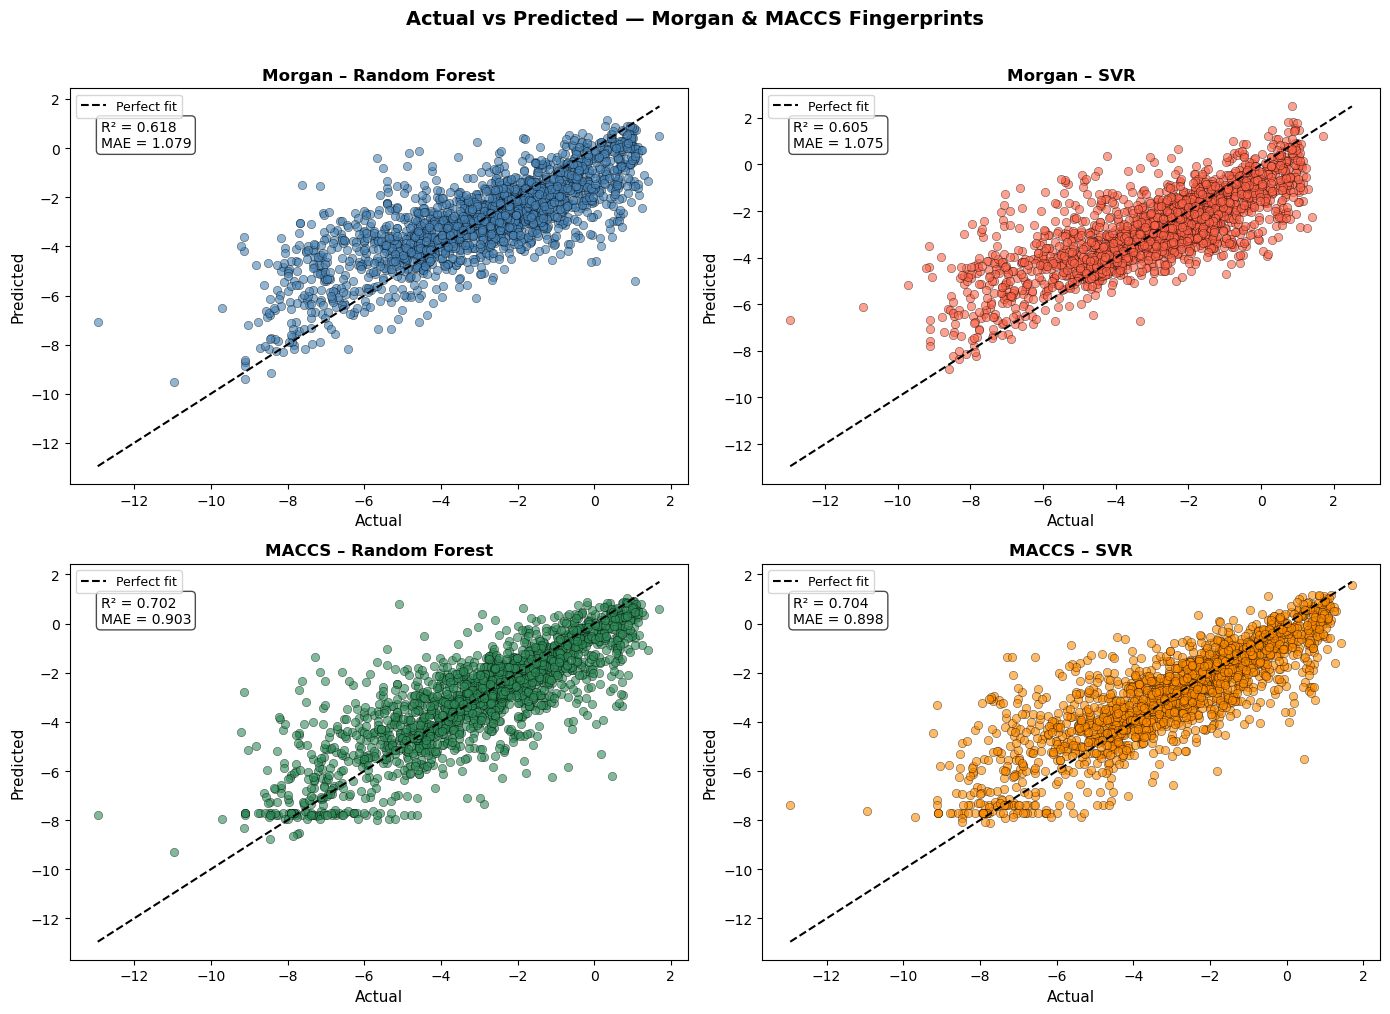

In [100]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

combos = [
    (test_y_morgan, prediction_morgan_rf,  r2_morgan_rf,  mae_morgan_rf,  'Morgan – Random Forest',  'steelblue'),
    (test_y_morgan, prediction_morgan_svm, r2_morgan_svm, mae_morgan_svm, 'Morgan – SVR',             'tomato'),
    (test_y_maccs,  prediction_maccs_rf,   r2_maccs_rf,   mae_maccs_rf,   'MACCS – Random Forest',   'seagreen'),
    (test_y_maccs,  prediction_maccs_svm,  r2_maccs_svm,  mae_maccs_svm,  'MACCS – SVR',             'darkorange'),
]

for ax, (y_true, y_pred, r2, mae, title, color) in zip(axes.flat, combos):
    # Convert to numpy arrays so .min()/.max() work
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.4)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.text(0.05, 0.92, f'R² = {r2:.3f}\nMAE = {mae:.3f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Actual vs Predicted — Morgan & MACCS Fingerprints', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

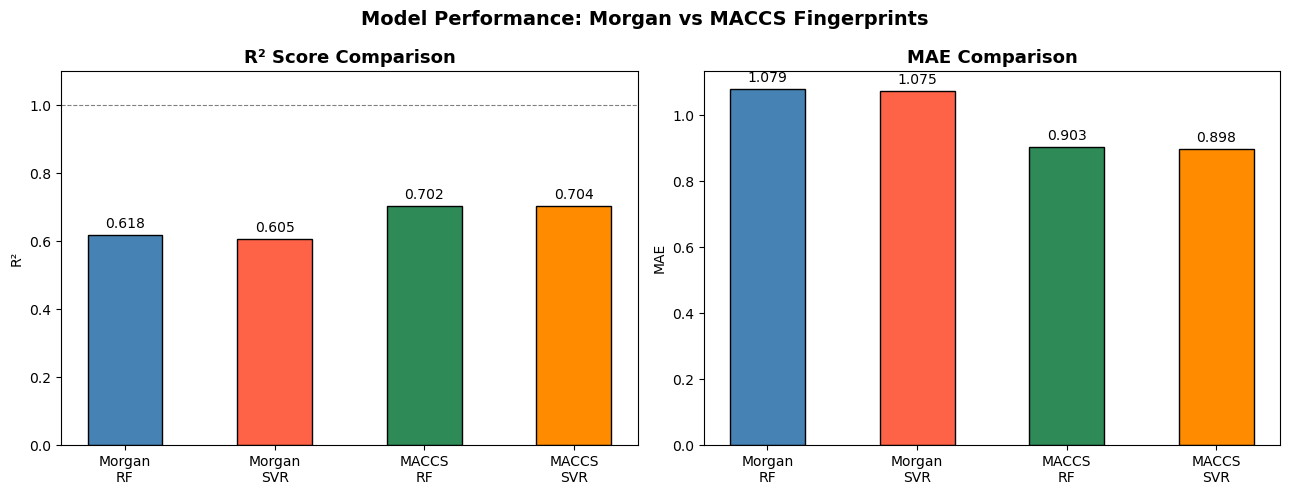

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels   = ['Morgan\nRF', 'Morgan\nSVR', 'MACCS\nRF', 'MACCS\nSVR']
r2_vals  = [r2_morgan_rf,  r2_morgan_svm,  r2_maccs_rf,  r2_maccs_svm]
mae_vals = [mae_morgan_rf, mae_morgan_svm, mae_maccs_rf, mae_maccs_svm]
colors   = ['steelblue', 'tomato', 'seagreen', 'darkorange']

# R²
bars = axes[0].bar(labels, r2_vals, color=colors, edgecolor='black', width=0.5)
axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# MAE
bars = axes[1].bar(labels, mae_vals, color=colors, edgecolor='black', width=0.5)
axes[1].bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
axes[1].set_title('MAE Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAE')

plt.suptitle('Model Performance: Morgan vs MACCS Fingerprints', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

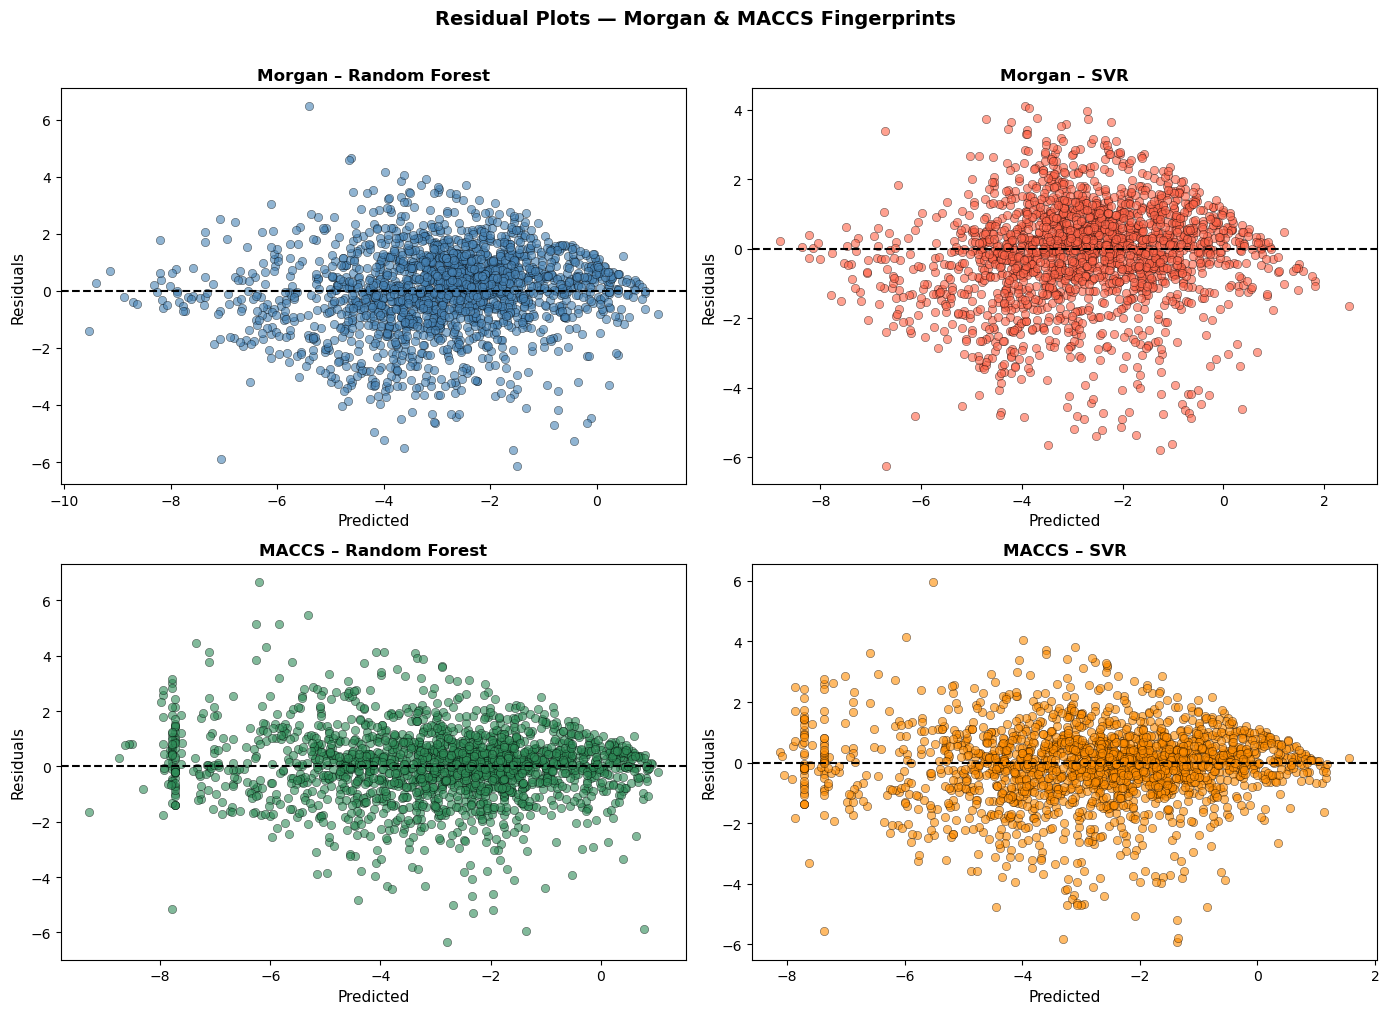

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (y_true, y_pred, title, color) in zip(axes.flat, [
    (test_y_morgan, prediction_morgan_rf,  'Morgan – Random Forest', 'steelblue'),
    (test_y_morgan, prediction_morgan_svm, 'Morgan – SVR',           'tomato'),
    (test_y_maccs,  prediction_maccs_rf,   'MACCS – Random Forest',  'seagreen'),
    (test_y_maccs,  prediction_maccs_svm,  'MACCS – SVR',            'darkorange'),
]):
    residuals = np.array(y_true) - np.array(y_pred)
    ax.scatter(y_pred, residuals, alpha=0.6, color=color, edgecolors='k', linewidths=0.4)
    ax.axhline(0, color='black', linestyle='--', lw=1.5)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Residual Plots — Morgan & MACCS Fingerprints', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()